**Лабораторная работа 4**

**Распознавание цифр с использованием набора данных MNIST**

*Импорт необходимых библиотек*

In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import ToTensor
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import cv2

*Загрузка данных*

In [2]:
train_data = torchvision.datasets.MNIST(root='./data', train=True, transform=ToTensor(), download=True)
test_data = torchvision.datasets.MNIST(root='./data', train=False, transform=ToTensor(), download=True)

*Разделение данных на обучающую тестовую и валидационную выборки*

In [3]:
train_data, val_data = random_split(train_data, [50000, 10000])
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

*Описание модели*

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)
        return x

*Инициализация модели и определение функций обучения и валидации*

In [5]:
model = MLP()
optimizer = optim.SGD(model.parameters(), lr=0.01)


def train_epoch(model, data_loader, optimizer, loss_fn):
    model.train()
    for X, Y in data_loader:
        optimizer.zero_grad()
        Y_pred = model(X)
        loss = loss_fn(Y_pred, Y)
        loss.backward()
        optimizer.step()


def evaluate_model(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, Y in data_loader:
            Y_pred = model(X)
            loss = loss_fn(Y_pred, Y)
            total_loss += loss.item()
    return total_loss / len(data_loader)

*Обучение*

In [6]:
num_epochs = 20
loss_fn = nn.CrossEntropyLoss()
for epoch in range(num_epochs):
    train_epoch(model, train_loader, optimizer, loss_fn)
    val_loss = evaluate_model(model, val_loader, loss_fn)
    print(f"Epoch {epoch + 1}, Validation Loss: {val_loss:.4f}")

Epoch 1, Validation Loss: 2.2860
Epoch 2, Validation Loss: 2.2222
Epoch 3, Validation Loss: 2.0901
Epoch 4, Validation Loss: 1.9085
Epoch 5, Validation Loss: 1.8179
Epoch 6, Validation Loss: 1.7784
Epoch 7, Validation Loss: 1.7577
Epoch 8, Validation Loss: 1.7268
Epoch 9, Validation Loss: 1.7012
Epoch 10, Validation Loss: 1.6855
Epoch 11, Validation Loss: 1.6749
Epoch 12, Validation Loss: 1.6671
Epoch 13, Validation Loss: 1.6611
Epoch 14, Validation Loss: 1.6564
Epoch 15, Validation Loss: 1.6525
Epoch 16, Validation Loss: 1.6492
Epoch 17, Validation Loss: 1.6465
Epoch 18, Validation Loss: 1.6441
Epoch 19, Validation Loss: 1.6419
Epoch 20, Validation Loss: 1.6401


*Оценка полученной модели*

In [7]:
def predict(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X, _ in loader:
            preds = model(X)
            _, pred_labels = torch.max(preds, 1)
            all_preds.extend(pred_labels.numpy())
    return all_preds


Y_pred = predict(model, test_data)
accuracy = accuracy_score(test_data.targets.numpy(), Y_pred)
cm = confusion_matrix(test_data.targets.numpy(), Y_pred)
print(f"Точность: {accuracy:.4f}")
print("Матрица ошибок:")
print(cm)

Точность: 0.8419
Матрица ошибок:
[[ 961    0    1    1    2    0    8    1    6    0]
 [   0 1107    3    4    1    0    5    2   13    0]
 [  12    2  907   17   22    0   17   17   34    4]
 [   5    0   23  927    2    0    4   16   24    9]
 [   2    2    4    1  918    0   17    1    4   33]
 [  73   12    9  264   54    0   47   38  364   31]
 [  15    3    5    3   13    0  912    0    7    0]
 [   6   18   32    1   13    0    0  925    4   29]
 [   9    7    9   21   10    0   20   12  872   14]
 [  16    6    3   15   46    0    1   19   13  890]]


*Визуализация*

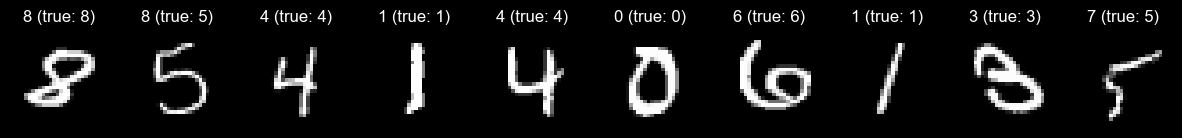

In [8]:
def visualize_predictions(images, labels, preds, num_samples=10):
    idxs = np.random.choice(len(images), size=num_samples, replace=False)
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, ax in zip(idxs, axes):
        ax.imshow(images[i].numpy().squeeze(), cmap='gray')
        ax.set_title(f"{preds[i]} (true: {labels[i]})")
        ax.axis('off')

    plt.show()


test_images, test_labels = next(iter(test_loader))
model.eval()
all_preds = []
with torch.no_grad():
    for X in test_images:
        preds = model(X)
        _, pred_labels = torch.max(preds, 1)
        all_preds.extend(pred_labels.numpy())
visualize_predictions(test_images, test_labels.numpy(), all_preds)

*Предварительная предобработка фотографии*

In [9]:
def preprocess_image(image_path, target_size=(28, 28)):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    img = img[start_y:start_y + min_dim, start_x:start_x + min_dim]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img

*Оценка вероятности принадлежности фрагмента к тому или иному классу*

In [10]:
def analyze_handwritten_digit(image_path):
    img = preprocess_image(image_path)

    img_tensor = torch.Tensor(img).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = F.softmax(output, dim=1).numpy()[0]
        predicted_class = np.argmax(probabilities)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(img, cmap='gray')
    ax1.set_title(f'Распознанная цифра: {predicted_class}', fontsize=14)
    ax1.axis('off')

    colors = ['green' if i == predicted_class else 'steelblue' for i in range(10)]
    bars = ax2.bar(range(10), probabilities, color=colors)
    ax2.set_xlabel('Класс (цифра)', fontsize=12)
    ax2.set_ylabel('Вероятность', fontsize=12)
    ax2.set_xticks(range(10))

    for bar, prob in zip(bars, probabilities):
        if prob > 0.05:
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f'{prob:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

*Испытания*

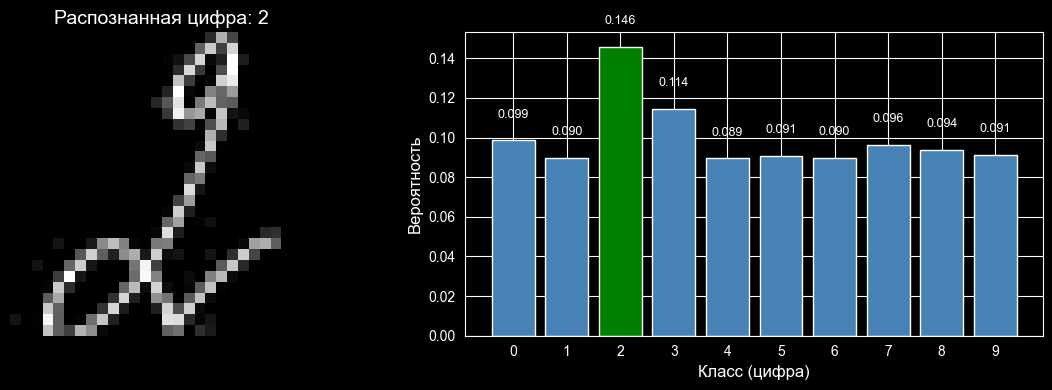

In [11]:
analyze_handwritten_digit("2.png")

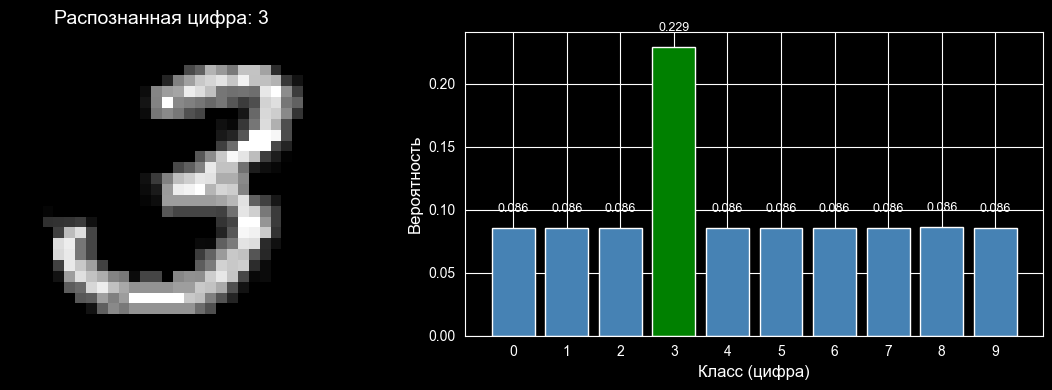

In [12]:
analyze_handwritten_digit("3.png")

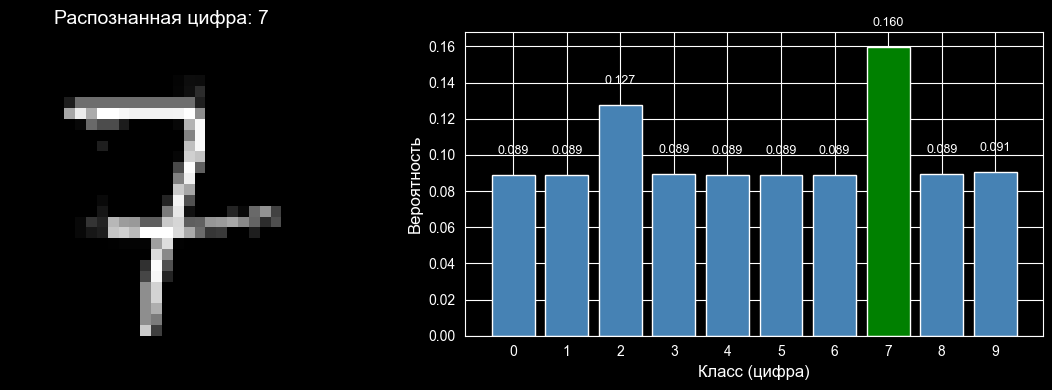

In [13]:
analyze_handwritten_digit("7.png")